# Project: Computational immunophenotyping of biomaterial-induced foreign body response
---
**Notebook**: 02_celltype_annotation

**Dataset:** [GSE203099](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE203099)  
**Author:** *Chinonye Precious Anams*


## 1. Biological context and objective

### 1.1 Immune and Stromal Dynamics in FBR
After biomaterial implantation, the **Foreign Body Response (FBR)** involves the coordinated recruitment and activation of:
* **Innate & Adaptive Immune Cells:** Neutrophils, macrophages, and T-cells.
* **Stromal Remodeling Units:** Driven largely by **fibroblasts** and **vascular-associated cells**.

Following the unbiased clustering performed in *Notebook 01*, the immediate requirement is to bridge the gap between mathematical clusters and biological reality by assigning identities using **canonical marker genes**.

### 1.2 Objective: Cluster Annotation
The goal of this notebook is to annotate major immune and stromal cell populations from the global **Leiden clusters** in the **GSE203099** dataset. 

> **Outcome:** This provides a defensible **“cellular map”** for downstream focused analyses, including:
> * Macrophage and fibroblast state programs.
> * Immune–fibroblast crosstalk mechanisms.
---

### Metadata

In [1]:
"""
Notebook: 02_celltype_annotation
Project: Computational immunophenotyping of biomaterial-induced foreign body response
Dataset: GSE203099
Goal: Annotate immune and stromal cell types from Leiden clustering
Author: Chinonye Precious Anams
"""

'\nNotebook: 02_celltype_annotation\nProject: Computational immunophenotyping of biomaterial-induced foreign body response\nDataset: GSE203099\nGoal: Annotate immune and stromal cell types from Leiden clustering\nAuthor: Chinonye Precious Anams\n'

## 2. Imports and data loading

In [2]:
from pathlib import Path
import scanpy as sc
import matplotlib.pyplot as plt

In [3]:
fig_dir = Path("../figures/annotation")
fig_dir.mkdir(parents=True, exist_ok=True)

In [4]:
adata = sc.read_h5ad("../data/processed/GSE203099_clustered.h5ad")
adata

AnnData object with n_obs × n_vars = 40039 × 21617
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

## 3. Quick dataset sanity checks

In [5]:
adata.shape

(40039, 21617)

In [6]:
adata.obs["leiden"].value_counts().head(10)

leiden
3     10872
0      6105
4      3266
7      3087
13     3059
10     2194
15     1766
2      1750
1      1607
11     1436
Name: count, dtype: int64

In [7]:
adata.obsm.keys()

KeysView(AxisArrays with keys: X_pca, X_umap)

These checks confirm that the processed AnnData object contains Leiden cluster assignments and low-dimensional embeddings required for marker-based annotation.


## 4. Marker gene panel for broad immune + stromal identities

### 4.1 Rationale
Clusters were annotated using canonical marker genes representing major immune and stromal compartments expected in FBR tissue. This approach prioritizes broad, defensible identities (e.g., macrophage/monocyte, fibroblast, T cell) rather than over-interpreting fine subtypes at this stage.


### 4.2 Define marker panel

In [8]:
marker_panel = {
    "Macrophage/Monocyte": ["Lyz2", "Adgre1", "Csf1r", "Cd68", "Lgals3", "Fcgr3"],
    "Fibroblast": ["Col1a1", "Col1a2", "Dcn", "Lum", "Col3a1", "Pdgfra"],
    "T cells": ["Cd3d", "Cd3e", "Trac", "Trbc1"],
    "NK cells": ["Nkg7", "Klrk1", "Prf1"],
    "Neutrophils": ["S100a8", "S100a9", "Ly6g", "Lcn2"],
    "Dendritic cells": ["Itgax", "Clec10a", "Flt3"],
    "B cells": ["Ms4a1", "Cd79a", "Cd74"],
    "Endothelial": ["Pecam1", "Kdr", "Rbp7", "Klf2"],
    "Pericyte/Smooth muscle": ["Rgs5", "Acta2", "Tagln"],
    "Epithelial (if present)": ["Epcam", "Krt8", "Krt18"],
    "Cycling": ["Mki67", "Top2a", "Tubb5"]
}

## 5. Visualize marker expression on UMAP

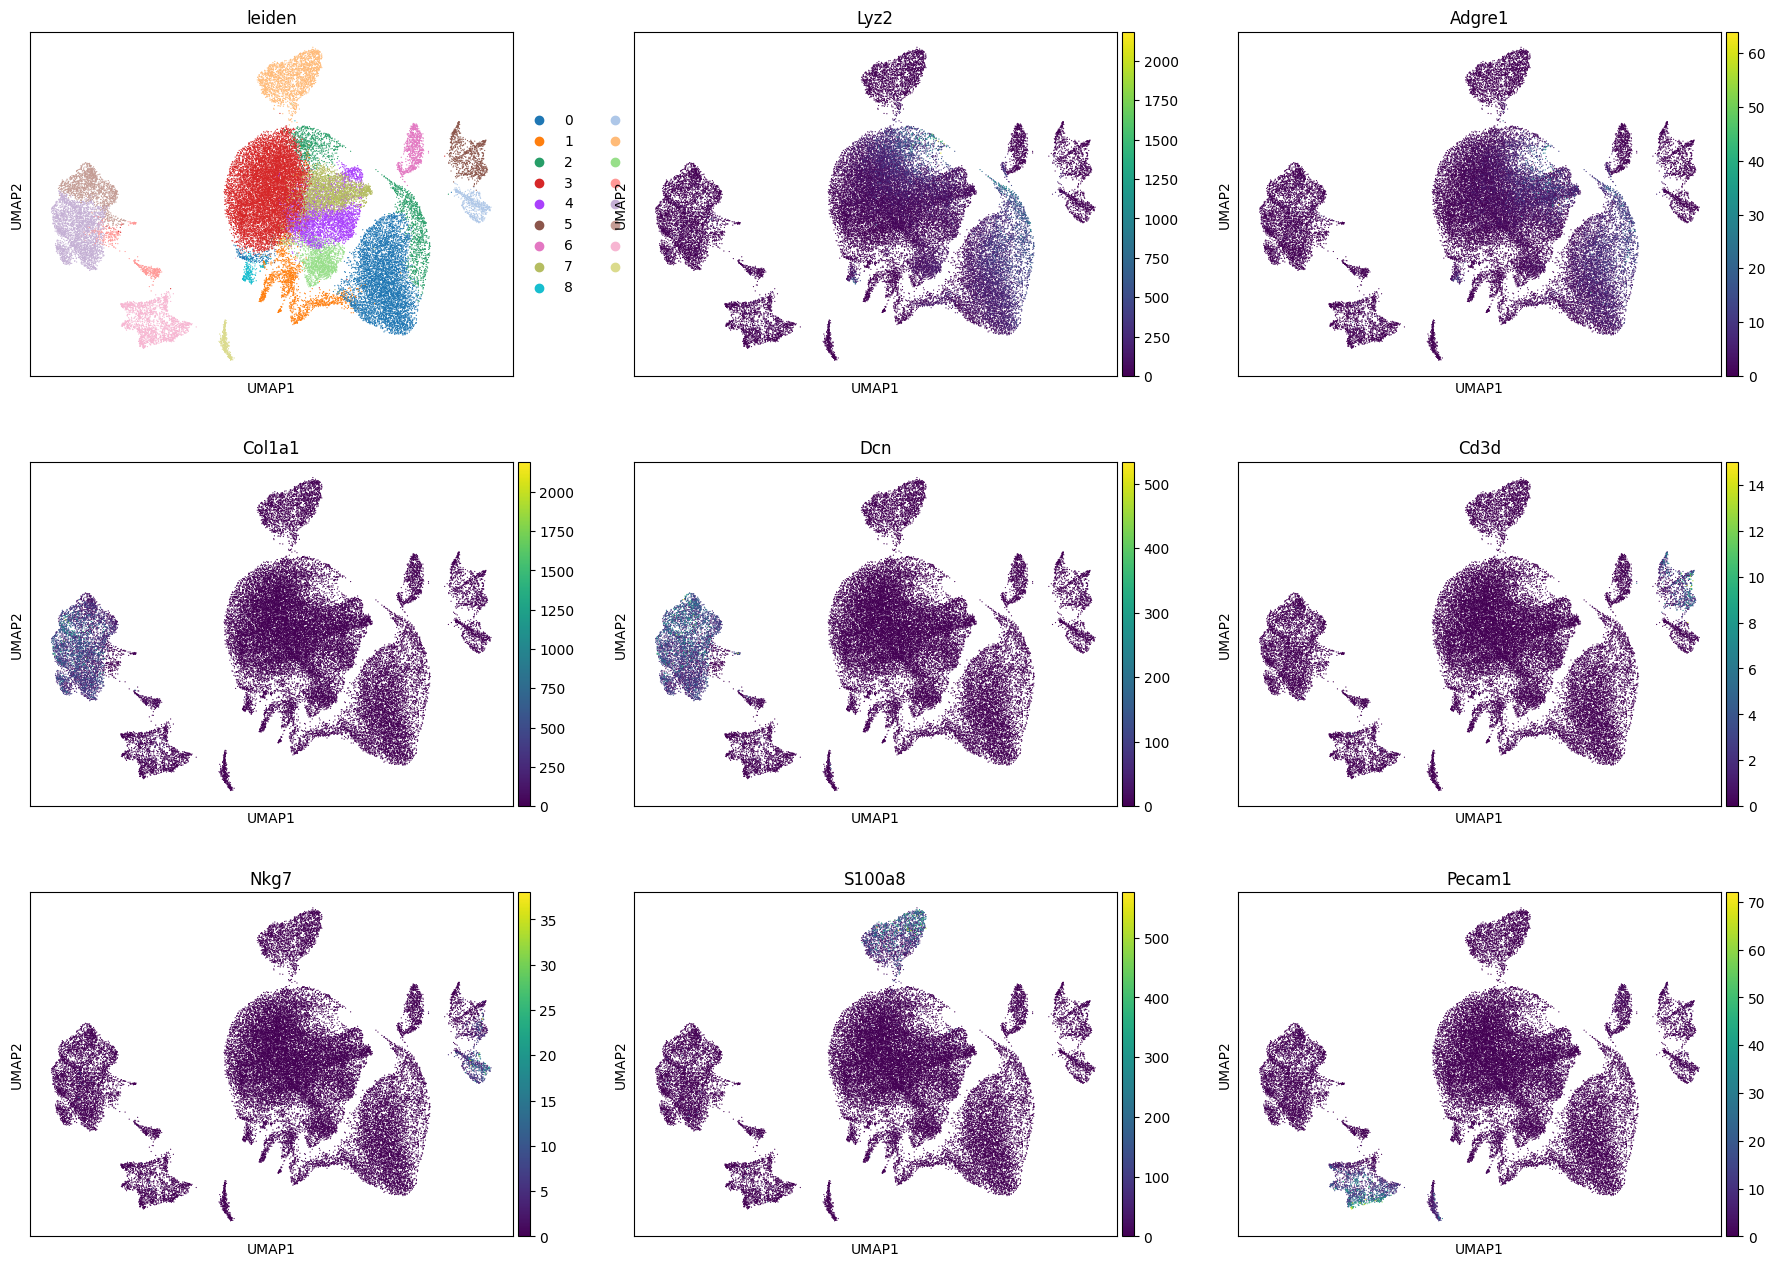

In [9]:
sc.pl.umap(
    adata,
    color=[
        "leiden",
        "Lyz2", "Adgre1",
        "Col1a1", "Dcn",
        "Cd3d",
        "Nkg7",
        "S100a8",
        "Pecam1"
    ],
    ncols=3,
    show=False
)

plt.savefig(
    fig_dir / "umap_marker_expression.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


Marker expression overlaid on the UMAP was used to associate Leiden clusters with broad immune and stromal identities. For example, clusters enriched for **Lyz2/Adgre1/Csf1r** were consistent with macrophage/monocyte populations, while clusters enriched for **Col1a1/Dcn/Lum** were consistent with fibroblasts. This provides qualitative support for downstream cluster-to-cell-type mapping.


## 6. Marker-based summary across clusters (dotplot + violin)

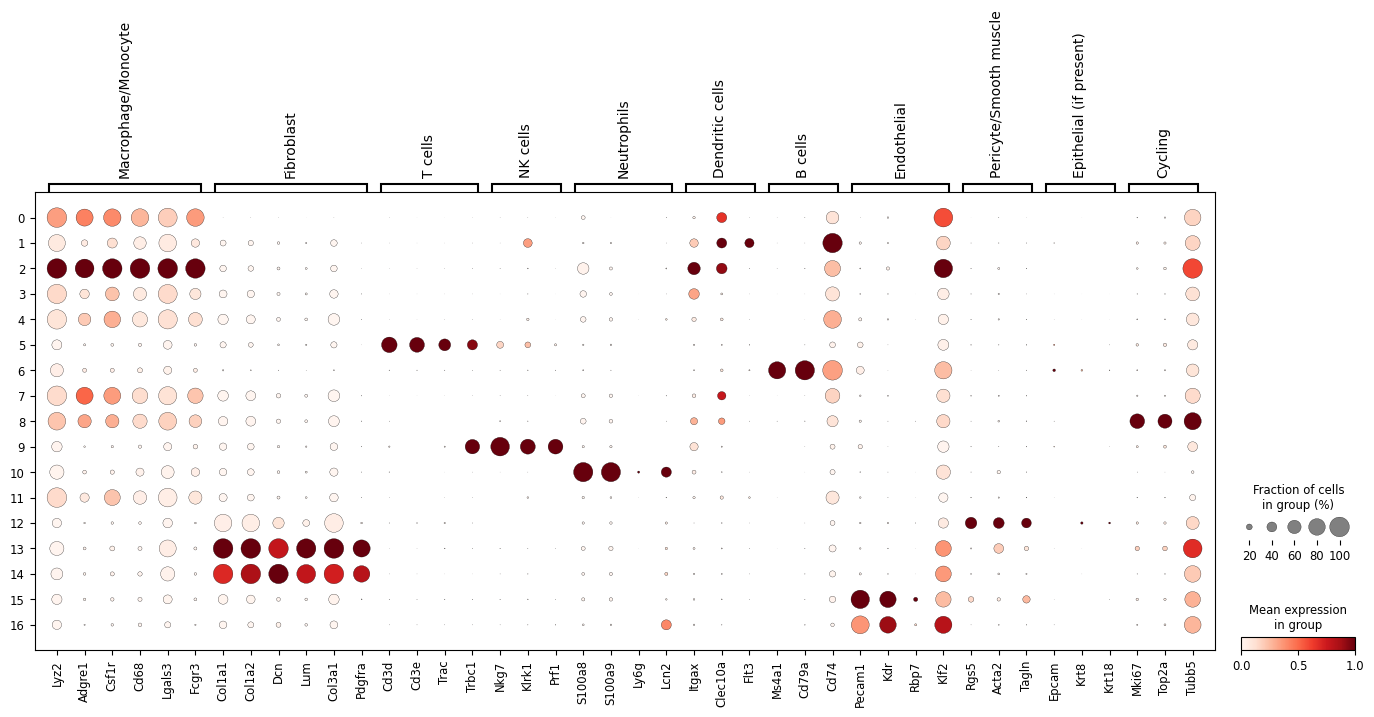

In [10]:
sc.pl.dotplot(
    adata,
    marker_panel,
    groupby="leiden",
    standard_scale="var",
    show=False
)

plt.savefig(
    fig_dir / "dotplot_marker_panel_by_cluster.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

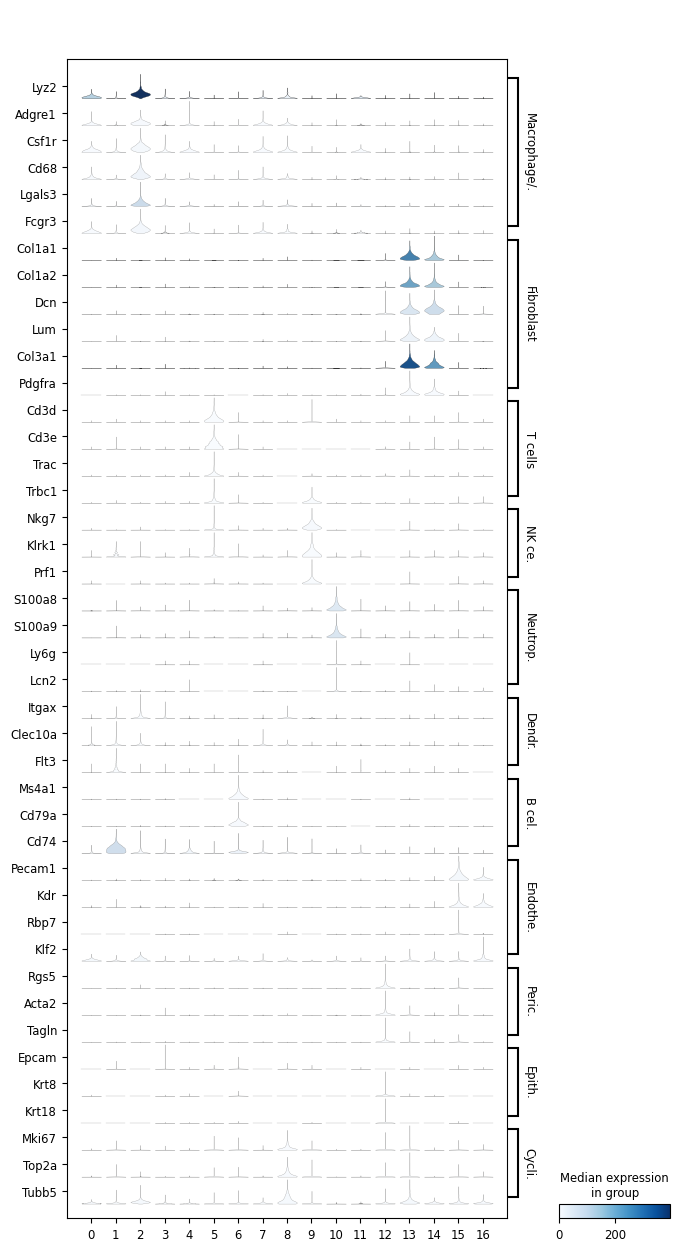

In [11]:
sc.pl.stacked_violin(
    adata,
    marker_panel,
    groupby="leiden",
    swap_axes=True,
    dendrogram=False,
    show=False
)

plt.savefig(
    fig_dir / "stacked_violin_marker_panel.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Dotplot and stacked violin summaries were used to confirm that marker expression patterns were consistent within clusters and supported broad cell-type assignments. This reduces reliance on single-marker decisions and improves the defensibility of annotation.


## 7. Assign cell-type labels to Leiden clusters

### 7.1 Define cluster → cell-type mapping

In [12]:
cluster_annotation = {
    # Macrophage / Monocyte
    "0": "Macrophage/Monocyte",
    "1": "Macrophage/Monocyte",
    "2": "Macrophage/Monocyte",
    "3": "Macrophage/Monocyte",
    "4": "Macrophage/Monocyte",
    "7": "Macrophage/Monocyte",
    "11": "Macrophage/Monocyte",

    # Cycling macrophages
    "8": "Macrophage (cycling)",

    # Fibroblast
    "12": "Fibroblast",
    "13": "Fibroblast",
    "14": "Fibroblast",

     # T cells
    "5": "T cell",

     # NK cells
    "9": "NK cell",

    # Neutrophils
    "10": "Neutrophil",

     # B cells
    "6": "B cell",

    # Endothelial
    "15": "Endothelial",
    "16": "Endothelial"
}   

### 7.2 Create cell_type column and Check annotation distribution

In [13]:
adata.obs["cell_type"] = adata.obs["leiden"].map(cluster_annotation).fillna("Unknown")

In [14]:
adata.obs["cell_type"].value_counts()

cell_type
Macrophage/Monocyte     28123
Fibroblast               5006
Neutrophil               2194
Endothelial              2114
T cell                    967
B cell                    810
NK cell                   569
Macrophage (cycling)      256
Name: count, dtype: int64

Leiden clusters were mapped to broad cell-type identities based on consistent marker expression patterns. Labels were intentionally kept at a conservative granularity (e.g., macrophage/monocyte rather than over-specified subtypes) to avoid over-interpretation at the global clustering stage.


## 8. Visualize annotated cell types on UMAP

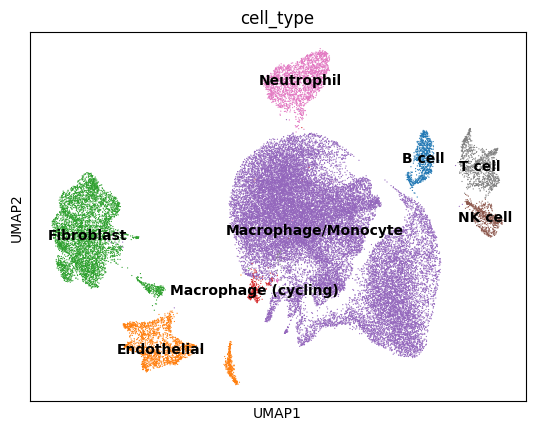

In [15]:
sc.pl.umap(
    adata,
    color="cell_type",
    legend_loc="on data",
    show=False
)

plt.savefig(
    fig_dir / "umap_cell_type_annotation.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

The annotated UMAP summarizes the global immune and stromal architecture induced by biomaterial implantation. This annotated reference enables targeted downstream analyses focusing on macrophage and fibroblast heterogeneity and their potential interactions in fibrotic programs.


## 9. Save annotated dataset for downstream notebooks

In [16]:
adata.write("../data/processed/GSE203099_annotated.h5ad")

## 10. Transition to macrophage + fibroblast state analysis

Macrophages are major immune drivers of the foreign body response, while fibroblasts are central executors of extracellular matrix remodeling and fibrosis. Having established broad cell-type identities, the next analysis focuses on **macrophage and fibroblast sub-states**, including inflammatory versus fibrotic-associated programs.
